# Stage-2 crop segmentation — loss ablation (BCE vs Tversky vs SuperVoxel)

Three U-Nets (`smp` U-Net, **resnet34** / imagenet encoder), **identical in every respect except the loss**:

| arm | epochs 1–10 | epochs 11–50 |
|---|---|---|
| `bce`        | `BCEWithLogitsLoss` | `BCEWithLogitsLoss` |
| `tversky`    | `BCEWithLogitsLoss` | `TverskyLoss(alpha=0.3, beta=0.7)` |
| `supervoxel` | `BCEWithLogitsLoss` | `SuperVoxelLoss2D(alpha=0.5, beta=0.5)` |

The 10-epoch BCE warm-up is applied to **all three** arms so the schedule is not a confounder
(SuperVoxel needs meaningful connected components before its topology term means anything).
Everything else is pinned: same pre-built crops, same augmentations, same AdamW + constant lr,
same seed (re-seeded before each arm, so all three start from identical weights and see identical
batch order / augmentation draws), same 50-epoch budget, same val split.

**Ground truth.** Each detector crop is supervised with the **filled PAGE `TextLine` polygon**, not
a thresholded ink mask. At inference the predicted binary crop mask is converted back to polygon
coordinates and a baseline, then written to PAGE-XML exactly as in `99_playground.ipynb`.

**Metrics, per epoch, on val:** polygon-mask IoU, Dice, precision and recall. The final experiment
also reports the official DIVA Java evaluator metrics after combining every segmenter with the
validation-selected CB55 RF-DETR and RT-DETR detectors.

Outputs: `best.pth` + `history.csv` per arm, a combined summary, and one qualitative figure
comparing the three arms on the same 3 val crops.

## Parameters

In [1]:
BACKBONE   = "resnet34"       # smp encoder for all three arms
FAMILY     = "diva"           # PAGE polygon supervision
SUBSET     = "CB55"           # CB55 | CS18 | CS863

CROP_H     = 256              # requested stage-2 crop geometry
CROP_W     = 1024             # requested stage-2 crop geometry
PAD        = 15               # px padding around each line bbox, as in dataset.py

EPOCHS     = 50
WARMUP_EPOCHS = 10            # BCE warm-up, identical in every arm
BATCH_SIZE = 4                # fits 256x1024 crops on the 8 GB GPU
NUM_WORKERS = 4
LR         = 3e-4             # constant, AdamW
WEIGHT_DECAY = 1e-4
SEED       = 1337

FORCE_RETRAIN = False         # set True only to overwrite completed polygon runs

ARMS = ["bce", "tversky", "supervoxel"]

## Dependencies

`supervoxel-loss` is not on PyPI — installed straight from GitHub. Safe to re-run.

In [2]:
try:
    from supervoxel_loss.loss import SuperVoxelLoss2D
    print("supervoxel-loss already installed")
except ImportError:
    %pip install -q git+https://github.com/AllenNeuralDynamics/supervoxel-loss
    from supervoxel_loss.loss import SuperVoxelLoss2D
    print("installed supervoxel-loss")

# Compatibility fix for Python >= 3.11: upstream calls random.sample(set, 1),
# but random.sample now requires a sequence. Patch only the library's local alias;
# the loss implementation and sampling distribution are otherwise unchanged.
import random as _random
import supervoxel_loss.critical_detection_2d as _sv_critical_2d

def _sample_supervoxel_population(population, k):
    return _random.sample(tuple(population), k)

_sv_critical_2d.sample = _sample_supervoxel_population
print("applied Python 3.11+ random.sample compatibility patch")

supervoxel-loss already installed
applied Python 3.11+ random.sample compatibility patch


## Setup + reproducibility

In [3]:
import os, sys, json, math, random, time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import albumentations as A
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, get_worker_info

# Work both when VS Code starts the kernel beside this notebook and when it starts at repo root.
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "dataset.py").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "50_modelling" / "02_2stage"
assert (NOTEBOOK_DIR / "dataset.py").exists(), f"Cannot locate 02_2stage from {Path.cwd()}"
REPO_ROOT = NOTEBOOK_DIR.parents[1]
sys.path.insert(0, str(NOTEBOOK_DIR))
from dataset import parse_xml_polygons, polygon_to_bbox   # reuse 02_2stage helpers

import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import TverskyLoss

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def seed_everything(seed: int):
    """Re-called before each arm so all three arms are bit-identical up to the loss."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


assert FAMILY == "diva", "this notebook currently resolves DIVA PAGE polygon paths"
FAM_DIR  = "diva-hisdb"
DATA_ROOT = REPO_ROOT / "00_data" / "DIVA-HisDB" / SUBSET
OUT_ROOT = REPO_ROOT / "80_models" / "02_2stage" / FAM_DIR / "crop_seg_loss_ablation_polygon_1024x256" / SUBSET
OUT_ROOT.mkdir(parents=True, exist_ok=True)

SPLIT_DIRS = {"train": "training", "val": "validation"}   # DIVA's own split, same as the yolo_dataset_* splits

def split_paths(split: str):
    d = SPLIT_DIRS[split]
    return (DATA_ROOT / f"img-{SUBSET}" / "img" / d,
            DATA_ROOT / f"PAGE-gt-{SUBSET}-TASK-2" / "TASK-2" / d)

for s in SPLIT_DIRS:
    for p in split_paths(s):
        print(f"{s:5s} {p}  {'ok' if p.exists() else 'MISSING'}")
print("device:", DEVICE, "| out:", OUT_ROOT)

train /home/artur/Thesis/fsl-tl-manuscripts/00_data/DIVA-HisDB/CB55/img-CB55/img/training  ok
train /home/artur/Thesis/fsl-tl-manuscripts/00_data/DIVA-HisDB/CB55/PAGE-gt-CB55-TASK-2/TASK-2/training  ok
val   /home/artur/Thesis/fsl-tl-manuscripts/00_data/DIVA-HisDB/CB55/img-CB55/img/validation  ok
val   /home/artur/Thesis/fsl-tl-manuscripts/00_data/DIVA-HisDB/CB55/PAGE-gt-CB55-TASK-2/TASK-2/validation  ok
device: cuda | out: /home/artur/Thesis/fsl-tl-manuscripts/80_models/instance_segmentation/rtdetr_bbox_unet/diva-hisdb/crop_seg_loss_ablation_polygon_1024x256/CB55


## Build the crops once (shared by all three arms)

For every `TextLine` in the PAGE GT: pad its bbox, crop the page image, shift and fill that line's
polygon inside the crop, then resize image and polygon mask together to `1024 × 256`.

This is the same fixed geometry and `[0, 1]` RGB preprocessing used by the PAGE-XML inference
pipeline. The crops and validation split are built once and shared by all three arms.

In [4]:
def build_crops(split: str):
    """Return fixed-size RGB crops and their filled PAGE TextLine polygon masks."""
    img_dir, xml_dir = split_paths(split)
    crops = []
    for fname in sorted(os.listdir(img_dir)):
        if not fname.lower().endswith((".jpg", ".png", ".tif")):
            continue
        stem = os.path.splitext(fname)[0]
        xml_path = xml_dir / f"{stem}.xml"
        if not xml_path.exists():
            print("  skip (no xml):", stem)
            continue

        img = cv2.cvtColor(cv2.imread(str(img_dir / fname)), cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]

        for poly in parse_xml_polygons(str(xml_path)):
            x1, y1, x2, y2 = polygon_to_bbox(poly)
            x1, y1 = max(0, x1 - PAD), max(0, y1 - PAD)
            x2, y2 = min(W, x2 + PAD), min(H, y2 + PAD)
            if x2 - x1 < 8 or y2 - y1 < 8:
                continue

            poly_mask = np.zeros((y2 - y1, x2 - x1), np.uint8)
            cv2.fillPoly(poly_mask, [(np.array(poly) - [x1, y1]).astype(np.int32)], 1)
            crop = img[y1:y2, x1:x2]
            mask = poly_mask
            if mask.sum() == 0:
                continue

            crop = cv2.resize(crop, (CROP_W, CROP_H), interpolation=cv2.INTER_AREA)
            mask = cv2.resize(mask, (CROP_W, CROP_H), interpolation=cv2.INTER_NEAREST)
            crops.append((crop, mask))
    return crops


t0 = time.time()
TRAIN_CROPS = build_crops("train")
VAL_CROPS   = build_crops("val")
print(f"train line-crops: {len(TRAIN_CROPS)}   val line-crops: {len(VAL_CROPS)}   ({time.time()-t0:.0f}s)")

train line-crops: 599   val line-crops: 305   (5s)


In [5]:
TRAIN_AUG = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Affine(scale=(0.95, 1.05), translate_percent=(-0.02, 0.02), rotate=(-2, 2),
             border_mode=cv2.BORDER_CONSTANT, fill=255, fill_mask=0, p=0.5),
    A.GaussNoise(p=0.2),
])  # no flips: script direction / ascender-descender orientation are meaningful


def _window(crop, mask, x0):
    """CROP_W-wide window starting at x0, right-padded (white / empty) if the crop is shorter."""
    c, m = crop[:, x0:x0 + CROP_W], mask[:, x0:x0 + CROP_W]
    if c.shape[1] < CROP_W:
        pad = CROP_W - c.shape[1]
        c = np.pad(c, ((0, 0), (0, pad), (0, 0)), constant_values=255)
        m = np.pad(m, ((0, 0), (0, pad)), constant_values=0)
    return c, m


def _to_tensor(crop, mask):
    x = crop.astype(np.float32) / 255.0  # matches evaluate.segment_crop exactly
    return (torch.from_numpy(x).permute(2, 0, 1).contiguous(),
            torch.from_numpy(mask.astype(np.float32)).unsqueeze(0))


class TrainCropDS(Dataset):
    """One fixed-size polygon crop per item, with shared augmentation policy."""
    def __init__(self, crops):
        self.crops = crops
        self.aug = TRAIN_AUG

    def __len__(self):
        return len(self.crops)

    def __getitem__(self, i):
        crop, mask = self.crops[i]
        c, m = crop, mask
        out = self.aug(image=c, mask=m)
        return _to_tensor(out["image"], out["mask"])


class ValCropDS(Dataset):
    """The fixed validation polygon crops, deterministic across arms and epochs."""
    def __init__(self, crops):
        self.crops = crops

    def __len__(self):
        return len(self.crops)

    def __getitem__(self, k):
        crop, mask = self.crops[k]
        img_t, mask_t = _to_tensor(crop, mask)
        return img_t, mask_t, k


def seed_worker(worker_id):
    """Give Python, NumPy and Albumentations the repeatable PyTorch worker seed."""
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    info = get_worker_info()
    aug = getattr(info.dataset, "aug", None) if info is not None else None
    if hasattr(aug, "set_random_seed"):
        aug.set_random_seed(worker_seed)


train_ds, val_ds = TrainCropDS(TRAIN_CROPS), ValCropDS(VAL_CROPS)
print("train polygon crops:", len(train_ds), " val polygon crops:", len(val_ds))

train polygon crops: 599  val polygon crops: 305


## Metrics

IoU, Dice, precision and recall are accumulated globally across the fixed validation polygon crops.

In [6]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    tp = fp = fn = 0
    for img, mask, _ in loader:
        img = img.to(DEVICE, non_blocking=True)
        pred = (torch.sigmoid(model(img)) > 0.5).float().cpu().numpy()[:, 0].astype(np.uint8)
        gt = mask.numpy()[:, 0].astype(np.uint8)
        p, g = pred, gt
        tp += int(((p == 1) & (g == 1)).sum())
        fp += int(((p == 1) & (g == 0)).sum())
        fn += int(((p == 0) & (g == 1)).sum())

    eps = 1e-9
    return {
        "iou":  tp / (tp + fp + fn + eps),
        "dice": 2 * tp / (2 * tp + fp + fn + eps),
        "precision": tp / (tp + fp + eps),
        "recall": tp / (tp + fn + eps),
    }

## The three arms

`loss_for_epoch(arm, ep)` is the *only* thing that differs between runs.

In [7]:
BCE = nn.BCEWithLogitsLoss()

def make_main_loss(arm):
    if arm == "bce":
        return BCE
    if arm == "tversky":
        return TverskyLoss(mode="binary", alpha=0.3, beta=0.7, from_logits=True)
    if arm == "supervoxel":
        return SuperVoxelLoss2D(alpha=0.5, beta=0.5, device=DEVICE)
    raise ValueError(arm)


def build_model():
    return smp.Unet(encoder_name=BACKBONE, encoder_weights="imagenet",
                    in_channels=3, classes=1).to(DEVICE)

## Train

In [8]:
def run_arm(arm: str):
    seed_everything(SEED)                     # identical init, batch order and augmentation draws
    if hasattr(train_ds.aug, "set_random_seed"):
        train_ds.aug.set_random_seed(SEED)     # also covers NUM_WORKERS=0
    g = torch.Generator(); g.manual_seed(SEED)
    dl_train = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                          pin_memory=(DEVICE == "cuda"), drop_last=True, generator=g,
                          worker_init_fn=seed_worker)
    dl_val   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=(DEVICE == "cuda"), worker_init_fn=seed_worker)

    model = build_model()
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    main_loss = make_main_loss(arm)

    out_dir = OUT_ROOT / arm
    out_dir.mkdir(parents=True, exist_ok=True)
    history, best_dice = [], -1.0

    for ep in range(1, EPOCHS + 1):
        warm = ep <= WARMUP_EPOCHS
        loss_fn = BCE if warm else main_loss
        model.train(); tot = 0.0
        for img, mask in dl_train:
            img, mask = img.to(DEVICE, non_blocking=True), mask.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(img), mask)
            loss.backward(); opt.step()
            tot += loss.item()
        tr_loss = tot / max(1, len(dl_train))

        m = evaluate(model, dl_val)
        m.update(arm=arm, epoch=ep, phase="warmup(bce)" if warm else arm, train_loss=tr_loss)
        history.append(m)
        pd.DataFrame(history).to_csv(out_dir / "history.csv", index=False)  # survive interrupted runs
        print(f"[{arm:10s}] ep {ep:02d}/{EPOCHS} ({m['phase']:12s})  loss {tr_loss:.4f} | "
              f"IoU {m['iou']:.4f}  Dice {m['dice']:.4f}  "
              f"precision {m['precision']:.4f}  recall {m['recall']:.4f}", flush=True)

        eligible = (arm == "bce") or (ep > WARMUP_EPOCHS)
        if eligible and m["dice"] > best_dice:       # switched arms must actually use their named loss
            best_dice = m["dice"]
            torch.save({"state_dict": model.state_dict(), "epoch": ep, "metrics": m,
                        "arm": arm, "backbone": BACKBONE},
                       out_dir / "best.pth")

    df = pd.DataFrame(history)
    df.to_csv(out_dir / "history.csv", index=False)
    print(f"[{arm}] best Dice {best_dice:.4f} -> {out_dir/'best.pth'}")
    return df


# Re-running this cell after an interruption keeps completed arms and restarts only
# an incomplete arm. Exact mid-arm continuation is intentionally avoided because the
# optimizer/RNG state was not checkpointed by the interrupted version.
histories = {}
for arm in ARMS:
    history_path = OUT_ROOT / arm / "history.csv"
    best_path = OUT_ROOT / arm / "best.pth"
    if not FORCE_RETRAIN and history_path.exists() and best_path.exists():
        saved = pd.read_csv(history_path)
        complete = len(saved) >= EPOCHS and int(saved["epoch"].max()) >= EPOCHS
        if complete and arm != "bce":
            checkpoint_epoch = int(torch.load(best_path, map_location="cpu", weights_only=False)["epoch"])
            complete = checkpoint_epoch > WARMUP_EPOCHS
    else:
        saved, complete = None, False

    if complete:
        histories[arm] = saved.sort_values("epoch").iloc[:EPOCHS].reset_index(drop=True)
        print(f"[{arm}] already complete — loaded {history_path}")
    else:
        if saved is not None:
            print(f"[{arm}] incomplete ({len(saved)}/{EPOCHS} epochs) — restarting this arm")
        histories[arm] = run_arm(arm)

[bce] incomplete (46/50 epochs) — restarting this arm


[bce       ] ep 01/50 (warmup(bce) )  loss 0.1955 | IoU 0.9032  Dice 0.9491  precision 0.9639  recall 0.9348


[bce       ] ep 02/50 (warmup(bce) )  loss 0.0809 | IoU 0.9149  Dice 0.9555  precision 0.9434  recall 0.9680


[bce       ] ep 03/50 (warmup(bce) )  loss 0.0663 | IoU 0.9198  Dice 0.9582  precision 0.9592  recall 0.9572


[bce       ] ep 04/50 (warmup(bce) )  loss 0.0596 | IoU 0.9173  Dice 0.9569  precision 0.9596  recall 0.9541


...

[supervoxel] ep 47/50 (supervoxel  )  loss 0.0133 | IoU 0.9137  Dice 0.9549  precision 0.9424  recall 0.9677


[supervoxel] ep 48/50 (supervoxel  )  loss 0.0147 | IoU 0.9260  Dice 0.9616  precision 0.9549  recall 0.9684


[supervoxel] ep 49/50 (supervoxel  )  loss 0.0132 | IoU 0.9239  Dice 0.9605  precision 0.9612  recall 0.9598


[supervoxel] ep 50/50 (supervoxel  )  loss 0.0129 | IoU 0.9258  Dice 0.9615  precision 0.9652  recall 0.9578


[supervoxel] best Dice 0.9632 -> /home/artur/Thesis/fsl-tl-manuscripts/80_models/instance_segmentation/rtdetr_bbox_unet/diva-hisdb/crop_seg_loss_ablation_polygon_1024x256/CB55/supervoxel/best.pth


## Results

,arm,best_epoch,iou@bestDice,dice@bestDice,precision@bestDice,recall@bestDice
0,bce,10,0.9287,0.9630,0.9651,0.9610
1,tversky,49,0.9274,0.9623,0.9502,0.9748
2,supervoxel,38,0.9291,0.9632,0.9641,0.9624


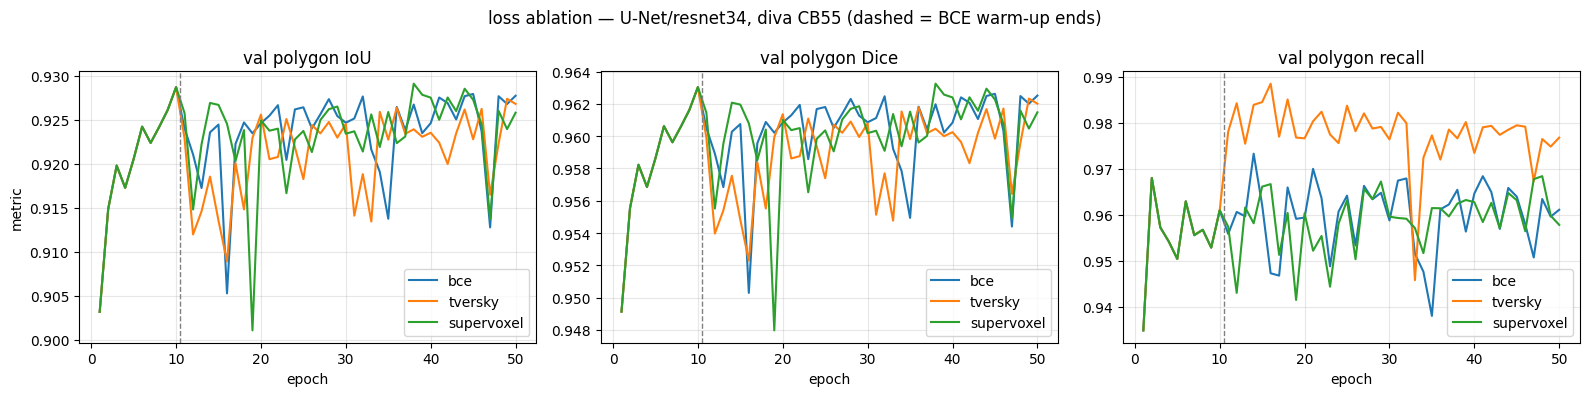

In [9]:
all_hist = pd.concat(histories.values(), ignore_index=True)
all_hist.to_csv(OUT_ROOT / "history_all_arms.csv", index=False)

cols = ["iou", "dice", "precision", "recall"]
summary_rows = []
for arm, h in histories.items():
    eligible_h = h if arm == "bce" else h[h["epoch"] > WARMUP_EPOCHS]
    best_idx = eligible_h["dice"].idxmax()
    summary_rows.append({"arm": arm,
                         "best_epoch": int(h.loc[best_idx, "epoch"]),
                         **{f"{c}@bestDice": h.loc[best_idx, c] for c in cols}})
summary = pd.DataFrame(summary_rows)
summary.to_csv(OUT_ROOT / "summary.csv", index=False)
display(summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric, title in zip(axes,
                             ["iou", "dice", "recall"],
                             ["val polygon IoU",
                              "val polygon Dice",
                              "val polygon recall"]):
    for arm, h in histories.items():
        ax.plot(h["epoch"], h[metric], label=arm)
    ax.axvline(WARMUP_EPOCHS + 0.5, color="gray", ls="--", lw=1)
    ax.set_title(title); ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend()
axes[0].set_ylabel("metric")
fig.suptitle(f"loss ablation — U-Net/{BACKBONE}, {FAMILY} {SUBSET} (dashed = BCE warm-up ends)")
fig.tight_layout(); fig.savefig(OUT_ROOT / "curves.png", dpi=150)
plt.show()

## Qualitative comparison — same 3 val crops, three arms

The same three validation polygon crops are shown for every arm.

bce: best.pth from epoch 10


tversky: best.pth from epoch 49


supervoxel: best.pth from epoch 38


saved -> /home/artur/Thesis/fsl-tl-manuscripts/80_models/instance_segmentation/rtdetr_bbox_unet/diva-hisdb/crop_seg_loss_ablation_polygon_1024x256/CB55/qualitative_3crops.png


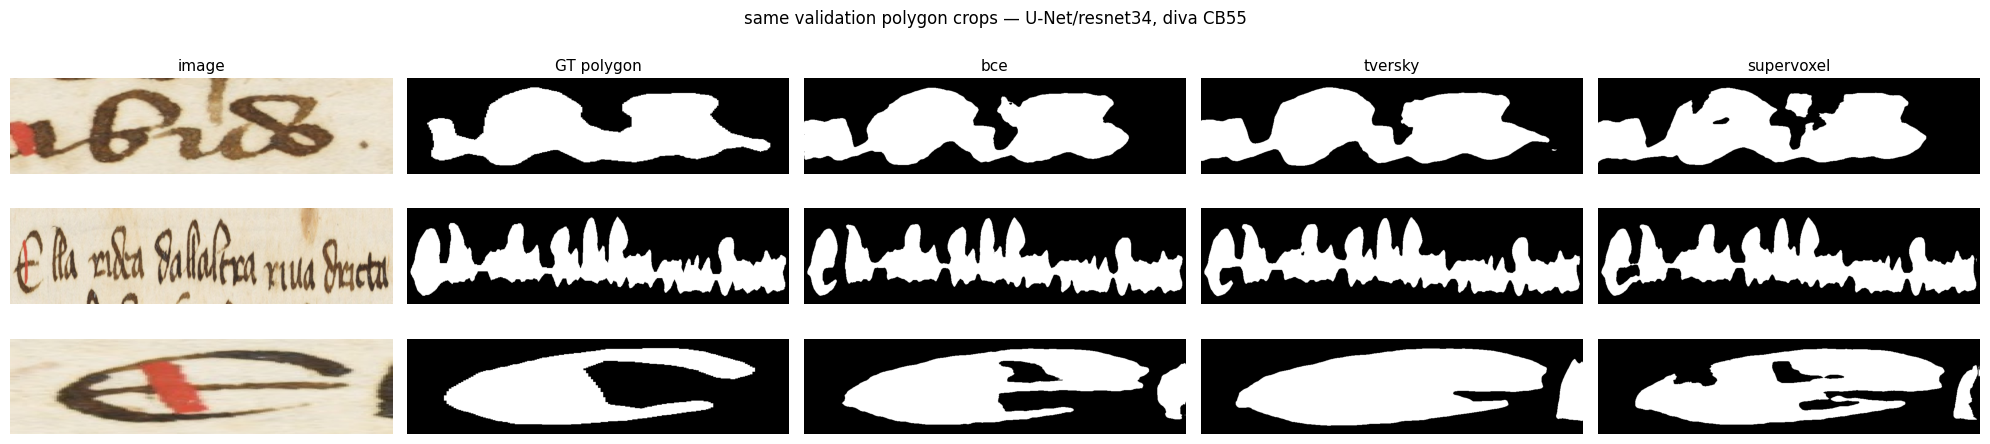

In [10]:
raw = VAL_CROPS
order = sorted(range(len(raw)), key=lambda k: -int(raw[k][1].sum()))
SHOW = order[:3]

preds = {}
for arm in ARMS:
    ck = torch.load(OUT_ROOT / arm / "best.pth", map_location=DEVICE, weights_only=False)
    model = build_model(); model.load_state_dict(ck["state_dict"]); model.eval()
    batch = torch.stack([_to_tensor(*raw[k])[0] for k in SHOW]).to(DEVICE)
    with torch.no_grad():
        preds[arm] = (torch.sigmoid(model(batch)) > 0.5).float().cpu().numpy()[:, 0]
    print(f"{arm}: best.pth from epoch {ck['epoch']}")

ncol = 2 + len(ARMS)
fig, axes = plt.subplots(len(SHOW), ncol, figsize=(4 * ncol, 1.6 * len(SHOW)))
for r, k in enumerate(SHOW):
    crop, gt = raw[k]
    panels = [("image", crop), ("GT polygon", gt)] + [(arm, preds[arm][r]) for arm in ARMS]
    for c, (title, panel) in enumerate(panels):
        ax = axes[r, c]
        ax.imshow(panel if panel.ndim == 3 else panel, cmap=None if panel.ndim == 3 else "gray")
        ax.set_axis_off()
        if r == 0:
            ax.set_title(title, fontsize=11)
fig.suptitle(f"same validation polygon crops — U-Net/{BACKBONE}, {FAMILY} {SUBSET}")
fig.tight_layout()
fig.savefig(OUT_ROOT / "qualitative_3crops.png", dpi=150, bbox_inches="tight")
print("saved ->", OUT_ROOT / "qualitative_3crops.png")
plt.show()